# Processing of RO-Crate for publishing
This notebook will read and RO-Crate file from galaxy, extract the provenance information as PROV-O in JSON-LD and save it into a new version of the RO-Crate.

1. read galaxy ro-crate
2. read the workflow file to get the prospective provenance
3. read the workflow run to get the retrospective provenance
4. merge the provenances into a PROV-O graph
5. save the PROV-O graph in the RO-Crate
6. get a publishable package consisting of RO-Crate + context (a JSON-LD file). The context metadata as JSON-LD is intended to facilitate discovery and interoperability
7. publish package to Invenio RDM (Zenodo if possible)


In [1]:
import zipfile
from pathlib import Path
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS, XSD, DCTERMS
import json


# library to support visualisation of graphs
from rdflib.extras.external_graph_libs import rdflib_to_networkx_graph

# pyvis used to display the graphs
from pyvis.network import Network


# Namespaces
PROV = Namespace("http://www.w3.org/ns/prov#")
SCHEMA = Namespace("http://schema.org/")
SKOS = Namespace("http://www.w3.org/2004/02/skos/core#")
PPLAN = Namespace("https://vocab.linkeddata.es/p-plan#")

file_formats = {"txt":"text/plain", "cif": "chemical/x-cif",
                "png":"image/png", "prj": "application/vnd.demeter.athena",
                "sp":"text/csv", "gds":"text/csv", "feffit":"text/plain", 
                "feff":"text/csv", "zip":"application/zip",
                "inp":"chemical/x-feff-input",
                "tabular": "text/plain",
                "h5": "application/x-hdf5",
                "jsonld": "application/ld+json"
               }

# read file from zipped RO-Crate file
def get_file_from_rocratezip(zip_file, file_name):
    roc_zip_file = zipfile.ZipFile(zip_file)
    return roc_zip_file.open(file_name)
    
# Read the zipped crate and get main metadata file
def load_rocrate_metadata(crate_file):
    roc_zip_file = zipfile.ZipFile(crate_file)
    f = get_file_from_rocratezip(crate_file, "ro-crate-metadata.json")
    crate = json.load(f)
    return crate["@graph"]

#Return all JSON-LD entities of a given @type.
def find_entities(graph, type_name):
    return [e for e in graph if type_name in e.get("@type", [])]

#Convert RO-Crate IDs to URIs.
def to_uri(crate_base, entity_id):
    return URIRef(crate_base + entity_id)

#Convert json-ld crate to turtle
def crate_to_turtle(crate_path, save_path):
    g = Graph()
    roc_zip_file = zipfile.ZipFile(crate_path)
    f = roc_zip_file.open("ro-crate-metadata.json")
    g.parse(f,format="json-ld")
    out_ttl = Path(save_path, "ro-crate-metadata.ttl")
    print(f"saving to {out_ttl}")
    g.serialize(destination=out_ttl, format="turtle")

# get galaxy workflow file from RO-Crate
def get_workflow_json(ro_crate_zip):
    graph = load_rocrate_metadata(ro_crate_zip)
    roc_files = find_entities(graph, "File")
    workflow_file = ""
    for a in roc_files:
        if a['@id'][-3:] == ".ga" :
            workflow_file = a['@id']
            break    
    f = get_file_from_rocratezip(ro_crate_zip, workflow_file)
    wf_ga_json = json.load(f)
    return wf_ga_json

# get txt containing entities RO-Crate metadata:
# invocation, datasets, etc
def get_roc_json_part(ro_crate_zip, file_name):
    graph = load_rocrate_metadata(ro_crate_zip)
    roc_file = ""
    roc_all_files = find_entities(graph, "File")
    for a in roc_all_files:
        if file_name in a['@id']:
            roc_file = a['@id']
            break
    f = get_file_from_rocratezip(ro_crate_zip, roc_file) 
    file_json = json.load(f)
    return file_json

# data sets are mapped to history objects
def get_history_mapped_ds(datasets_json, history_mapping):
    ds_id = ""
    for ds in datasets_json:
        chain = ds.get("copied_from_history_dataset_association_id_chain", [])
        if history_mapping in chain or history_mapping == ds["encoded_id"]:
            ds_id = ds["encoded_id"]
    return ds_id

# link ds generator to corresponding wf step
def get_wf_step(ds_uri, a_graph):
    
    ds_label =  get_a_label(a_graph, ds_uri)
    ret_val = None
    # fetch steps have the ds_name as the label
    for an_activity, p, o in a_graph.triples((None, RDFS.label, Literal(ds_label))):
        ret_val = an_activity                
    return ret_val

# add custom labels to activities
def custom_labels(a_graph):
    for an_activity in a_graph.subjects(RDF.type, PROV.Activity):
        #print(f"Activity {an_activity}")
        for an_agent in a_graph.objects(an_activity, PROV.wasAssociatedWith):
            #print(f"Activity {an_activity} associated with {an_agent}")
            for agent_label in a_graph.objects(an_agent, RDFS.label):
                #print(f"Agent label: {agent_label}")
                d_label = str(agent_label)
                pref_label = ""
                if d_label == "larch_athena":
                    pref_label = "process and normalise XAS"
                elif d_label == "larch_artemis":
                    pref_label = "FEFF fit of XAS"
                elif d_label == "larch_select_paths":
                    pref_label = "select FEFF paths"
                elif d_label == "larch_feff":
                    pref_label = "calculate FEFF paths from crystal"
                elif d_label == "larch_lcf":
                    pref_label = "linear combination fit of XAS"
                elif d_label == "larch_plot":
                    pref_label = "plot XAS data"
                elif d_label == "larch_criteria_report":
                    pref_label = "report on FEFF fitting"
                elif d_label == "DATA_FETCH":
                    pref_label = "fetch data from history"
                elif d_label == "EXTRACT_DATASET":
                    pref_label = "extract dataset from collection"
                    
            if pref_label != "":
                a_graph.add((an_activity, SKOS.prefLabel, Literal(pref_label)))

# get label associated to a subject
def get_a_label(graph_thing, a_subject):
    # Try SKOS prefLabel
    for a_label in graph_thing.objects(a_subject, SKOS.prefLabel):
        return str(a_label)

    # Try RDFS label
    for a_label in graph_thing.objects(a_subject, RDFS.label):
        return str(a_label)

    return ""

# lookup the collections table to find the jobs associated to steps
def find_jobs_by_hda_id(invoked_jobs, data_collections, hda_list):
    jobs_for_step = []
    # Build lookup maps 
    # lookup map for jobs by hda_id
    jobs_by_output_hda = {
          list(job['output_dataset_mapping'].values())[0][0]: job for job in invoked_jobs
        }
    # lookup map for collections by collection id
    collections_by_id = {c['encoded_id']: c for c in data_collections}
    
    for hda_id in hda_list:
        collection = collections_by_id.get(hda_id)
        if not collection:
            continue
    
        for element in collection['collection']['elements']:
            element_hda_id = element['hda']['encoded_id']
    
            job = jobs_by_output_hda.get(element_hda_id)
            if job:
                #print(f"Found job {job['encoded_id']} for HDA {element_hda_id}")
                jobs_for_step.append(job['encoded_id'])
    #print (f"step id: {step_id}, jobs: {jobs_for_step}")
    return jobs_for_step

# lookup output dataset ids to get jobs associated to steps
def find_jobs_by_ds_ids(invoked_jobs, ds_ids_list):
    jobs_for_step = []
    # Build lookup maps 
    # lookup map for jobs by hda_id
    jobs_by_output_hda = {
          list(job['output_dataset_mapping'].values())[0][0]: job for job in invoked_jobs
        }    
    for ds_id in ds_ids_list:   
            job = jobs_by_output_hda.get(ds_id)
            if job:
                jobs_for_step.append(job['encoded_id'])
    return jobs_for_step

# extract steps from wf and invocation files to create prov plan
def roc_provo(crate_path, out_path, output_file="galaxy_run_prov.ttl"):
    workflow_file = ""
    invocation_file = "" 

    # Load workflow (prospective provenance)
    wf = get_workflow_json(crate_path)
    steps = wf.get("steps", {})

    # Load invocation (retrospective provenance)
    inv = get_roc_json_part(crate_path,"invocation_attrs.txt")
    inv_steps = inv[0].get("steps", {})

    # load implicit job collections ()
    # these are parallelised executions from a single step in the workflow
    implicit_job_links = get_roc_json_part(crate_path, "implicit_collection_jobs_attrs.txt")
    
    # Load dataset attributes (encoding, names, ) 
    # to gather dataset attributes
    ds_attributes = get_roc_json_part(crate_path,"datasets_attrs.txt")

    # load ds collections
    # these collections map to grouped inputs (using lists) which are unpacked by fetch data
    ds_collections = get_roc_json_part(file_path, "collections_attrs.txt")

    # Load job attributes
    # gather input links
    invoked_jobs = get_roc_json_part(crate_path,"jobs_attrs.txt")
    
    g = Graph()

    # define namespaces in graph
    for p, ns in [("prov", PROV), ("schema", SCHEMA), ("skos", SKOS), ("p-plan", PPLAN)]:
        g.bind(p, ns)

    base = "/"

    # --- 1. Workflow definition as prov:Plan ---
    wf_uri = URIRef(base + "workflow")
    g.add((wf_uri, RDF.type, PPLAN.Plan))
    g.add((wf_uri, RDFS.label, Literal(wf.get("name", "Galaxy Workflow"))))

    # --- 2. Prospective provenance: workflow steps ---
    for step_id, step in steps.items():
        step_uri = URIRef(base + f"step/{step_id}")
        g.add((step_uri, RDF.type, PPLAN.Step))
        step_label = step.get("label") or step.get("tool_id")
        g.add((step_uri, RDFS.label, Literal(step_label)))

        # Link step to workflow plan
        g.add(( step_uri, PPLAN.isStepOfPlan, wf_uri))

        # Prospective inputs
        for inp in step.get("input_connections", {}).values():
            if isinstance(inp, dict) and "id" in inp:
                src = URIRef(base + f"step/{inp['id']}")
                g.add((step_uri, PPLAN.isPrecededBy, src))
    
    # --- 3. Retrospective provenance: actual execution --- 
    # invocations are only used to link actities to wf steps
    # can this code be simplified
    for inv_step in inv_steps:   
        job = inv_step.get("job")
        job_collection_prop = inv_step.get("implicit_collection_jobs")
        job_ids = []
        
        if job: 
            job_ids = [job['encoded_id']]
        elif job_collection_prop:
            job_collection_id = job_collection_prop.get("encoded_id") 
            for a_job_collection in implicit_job_links:
                if a_job_collection['encoded_id'] == job_collection_id:
                    job_ids = a_job_collection['jobs']
        else: 
            ds_links = []

            if inv_step.get("output_collections", []) != []:
                # Searching for collections
                for out in inv_step.get("output_collections", []):
                    ds_links.append(out['dataset_collection']['encoded_id'])
                
                job_ids += find_jobs_by_hda_id(invoked_jobs, ds_collections, ds_links)
                
            if inv_step.get("outputs", []) != []:
                # Searching for simple outputs
                for additional in inv_step.get("outputs", []):
                    ds_links.append(additional['dataset']['encoded_id'])
                job_ids += find_jobs_by_ds_ids(invoked_jobs, ds_links)
                if job_ids == []:
                    # try copied_from_history_dataset_association
                    temp_coll_ids = []
                    for a_coll_id in ds_links:
                        for a_ds in ds_attributes:
                            if a_ds['encoded_id'] == a_coll_id:
                                temp_coll_ids.append(a_ds['copied_from_history_dataset_association_id_chain'][0])
                    if temp_coll_ids != []:
                        job_ids += find_jobs_by_ds_ids(invoked_jobs, temp_coll_ids)
            if ds_links == []:
                print(inv_step)
                continue

        step_index = f"{inv_step['order_index']}"
        step_uri = URIRef(base + f"step/{step_index}")
        for a_job_id in job_ids:
            act_uri = URIRef(base + f"run/{a_job_id}")   
            g.add((act_uri, PPLAN.correspondsToStep, step_uri))

    # Add datset attributes
    for a_ds in ds_attributes:
        ent_uri = (URIRef(base + f"dataset/{a_ds['encoded_id']}"))
        format_str =  file_formats[a_ds['extension']]

        g.add((ent_uri, RDF.type, PROV.Entity)) # duplicated only used for WF_inputs which are not in invocation
        g.add((ent_uri, DCTERMS.format, Literal(format_str)))
        g.add((ent_uri, DCTERMS.description, Literal(a_ds['info'])))
        g.add((ent_uri, SCHEMA.name, Literal(a_ds['file_name'])))
        g.add((ent_uri, SKOS.prefLabel, Literal(a_ds['name']) ))

    # Add the missing links to inputs
    for a_job in invoked_jobs:
        job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
        # link all used datasets to activites
        for a_mapping in a_job['input_dataset_mapping']:
            for a_ds_id in  a_job['input_dataset_mapping'][a_mapping]:
                ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                g.add((job_uri, PROV.used, ds_uri))
                
    for a_job in invoked_jobs:
        job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
        tool_label = a_job['tool_id'].lstrip("_").rstrip("_")
        tool_uri = URIRef(f"/srv/galaxy/var/shed_tools/{a_job['tool_id']}")# causing problems
        tool_version = a_job['tool_version']
        if "toolshed" in a_job['tool_id']:
            tool_label, tool_version  =   a_job['tool_id'].split("/")[-2:]
        elif a_job['command_line']:
             tool_uri = URIRef(str(a_job['command_line'].split(' ')[1].strip("'")))
        else:
            tool_uri = URIRef(base + f"galaxy_tool/{tool_label.lower()}")

        g.add((tool_uri, RDF.type, PROV.SoftwareAgent))
        g.add((tool_uri, RDFS.label, Literal(tool_label)))
        g.add((tool_uri, SCHEMA.softwareVersion, Literal(tool_version)))
        # This should only add labes for datafetch activites which are not invocations
        g.add((job_uri, RDF.type, PROV.Activity))
        g.add((job_uri, RDFS.label, Literal(tool_label)))
        g.add((job_uri, PROV.wasAssociatedWith, tool_uri))

        # link output_dataset_mappings
        for a_mapping in a_job['output_dataset_mapping']:
            for a_mapping_id in  a_job['output_dataset_mapping'][a_mapping]:
                a_ds_id = get_history_mapped_ds(ds_attributes, a_mapping_id)
                ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                g.add((ds_uri, PROV.wasGeneratedBy, job_uri)) #already done for most only pending for data fetch
                g.add((ds_uri, PROV.wasAttributedTo, tool_uri))
                
                # these are also for data fetch only
                # link to associated plan activity
                step_uri = get_wf_step(ds_uri, g)
                if step_uri != None:
                    g.add((job_uri, PPLAN.correspondsToStep, step_uri))
        
        for a_mapping in a_job['input_dataset_mapping']:
            for a_ds_id in  a_job['input_dataset_mapping'][a_mapping]:
                ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                g.add((ds_uri, PROV.wasAttributedTo, tool_uri))
                
    # Assing human readable labels to activities
    custom_labels(g)
    
    # --- Save ---
    save_ttl = Path(out_path, output_file)
    g.serialize(destination=save_ttl, format="turtle")
    
    graph_context={
            "@vocab": str(PROV),
            "prov": str(PROV),
            "p-plan": str(PPLAN),
            "schema": str(SCHEMA),
            "skos": str(SKOS),
            "rdfs": str(RDFS),
            "dcterms": str(DCTERMS),
        }
    save_json = Path(out_path, output_file[:-4]+".json")
    g.serialize(destination=save_json, format="json-ld", 
                context=graph_context, auto_compact=True, indent=2)
    return g   

def roc_provo_rw(crate_path, out_path, output_file="galaxy_run_prov.ttl"):
    workflow_file = ""
    invocation_file = "" 

    # Load workflow (prospective provenance)
    wf = get_workflow_json(crate_path)
    steps = wf.get("steps", {})

    # Load invocation (retrospective provenance)
    inv = get_roc_json_part(crate_path,"invocation_attrs.txt")
    inv_steps = inv[0].get("steps", {})

    # load implicit job collections ()
    # these are parallelised executions from a single step in the workflow
    implicit_job_links = get_roc_json_part(crate_path, "implicit_collection_jobs_attrs.txt")
    
    # Load dataset attributes (encoding, names, ) 
    # to gather dataset attributes
    ds_attributes = get_roc_json_part(crate_path,"datasets_attrs.txt")

    # load ds collections
    # these collections map to grouped inputs (using lists) which are unpacked by fetch data
    ds_collections = get_roc_json_part(file_path, "collections_attrs.txt")

    # Load job attributes
    # gather input links
    invoked_jobs = get_roc_json_part(crate_path,"jobs_attrs.txt")
    
    g = Graph()

    # define namespaces in graph
    for p, ns in [("prov", PROV), ("schema", SCHEMA), ("skos", SKOS), ("p-plan", PPLAN)]:
        g.bind(p, ns)

    base = "/"

    # --- 1. Workflow definition as prov:Plan ---
    wf_uri = URIRef(base + "workflow")
    g.add((wf_uri, RDF.type, PPLAN.Plan))
    g.add((wf_uri, RDFS.label, Literal(wf.get("name", "Galaxy Workflow"))))

    # --- 2. Prospective provenance: workflow steps ---
    for step_id, step in steps.items():
        step_uri = URIRef(base + f"step/{step_id}")
        g.add((step_uri, RDF.type, PPLAN.Step))
        step_label = step.get("label") or step.get("tool_id")
        g.add((step_uri, RDFS.label, Literal(step_label)))

        # Link step to workflow plan
        g.add(( step_uri, PPLAN.isStepOfPlan, wf_uri))

        # Prospective inputs
        for inp in step.get("input_connections", {}).values():
            if isinstance(inp, dict) and "id" in inp:
                src = URIRef(base + f"step/{inp['id']}")
                g.add((step_uri, PPLAN.isPrecededBy, src))
    
    # --- 3. Retrospective provenance: actual execution --- 
    # invocations are only used to link actities to wf steps
    # can this code be simplified
    for inv_step in inv_steps:
        job_ids = []

        job = inv_step.get("job")
        job_collection = inv_step.get("implicit_collection_jobs")

        if job:
            job_ids = [job["encoded_id"]]

        elif job_collection:
            coll_id = job_collection.get("encoded_id")
            for jc in implicit_job_links:
                if jc["encoded_id"] == coll_id:
                    job_ids = jc["jobs"]
                    break

        else:
            ds_links = []
    
            for out in inv_step.get("output_collections", []):
                ds_links.append(out["dataset_collection"]["encoded_id"])
    
            if ds_links:
                job_ids += find_jobs_by_hda_id(invoked_jobs, ds_collections, ds_links)
    
            for out in inv_step.get("outputs", []):
                ds_links.append(out["dataset"]["encoded_id"])
    
            if ds_links:
                job_ids += find_jobs_by_ds_ids(invoked_jobs, ds_links)
    
                if not job_ids:
                    # fallback to copied_from_history_dataset_association
                    copied_ids = [
                        ds["copied_from_history_dataset_association_id_chain"][0]
                        for ds in ds_attributes
                        if ds["encoded_id"] in ds_links
                    ]
                    if copied_ids:
                        job_ids += find_jobs_by_ds_ids(invoked_jobs, copied_ids)
    
            if not ds_links:
                # to verify if there are unmatched steps
                print(inv_step)
                continue
    
        step_uri = URIRef(base + f"step/{inv_step['order_index']}")
    
        for job_id in job_ids:
            act_uri = URIRef(base + f"run/{job_id}")
            g.add((act_uri, PPLAN.correspondsToStep, step_uri))

    # Add datset attributes
    for a_ds in ds_attributes:
        ent_uri = (URIRef(base + f"dataset/{a_ds['encoded_id']}"))
        format_str =  file_formats[a_ds['extension']]

        g.add((ent_uri, RDF.type, PROV.Entity)) # duplicated only used for WF_inputs which are not in invocation
        g.add((ent_uri, DCTERMS.format, Literal(format_str)))
        g.add((ent_uri, DCTERMS.description, Literal(a_ds['info'])))
        g.add((ent_uri, SCHEMA.name, Literal(a_ds['file_name'])))
        g.add((ent_uri, SKOS.prefLabel, Literal(a_ds['name']) ))

    # Add the missing links to inputs
    for a_job in invoked_jobs:
        job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
        # link all used datasets to activites
        for a_mapping in a_job['input_dataset_mapping']:
            for a_ds_id in  a_job['input_dataset_mapping'][a_mapping]:
                ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                g.add((job_uri, PROV.used, ds_uri))
                
    for a_job in invoked_jobs:
        job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
        tool_label = a_job['tool_id'].lstrip("_").rstrip("_")
        tool_uri = URIRef(f"/srv/galaxy/var/shed_tools/{a_job['tool_id']}")# causing problems
        tool_version = a_job['tool_version']
        if "toolshed" in a_job['tool_id']:
            tool_label, tool_version  =   a_job['tool_id'].split("/")[-2:]
        elif a_job['command_line']:
             tool_uri = URIRef(str(a_job['command_line'].split(' ')[1].strip("'")))
        else:
            tool_uri = URIRef(base + f"galaxy_tool/{tool_label.lower()}")

        g.add((tool_uri, RDF.type, PROV.SoftwareAgent))
        g.add((tool_uri, RDFS.label, Literal(tool_label)))
        g.add((tool_uri, SCHEMA.softwareVersion, Literal(tool_version)))
        # This should only add labes for datafetch activites which are not invocations
        g.add((job_uri, RDF.type, PROV.Activity))
        g.add((job_uri, RDFS.label, Literal(tool_label)))
        g.add((job_uri, PROV.wasAssociatedWith, tool_uri))

        # link output_dataset_mappings
        for a_mapping in a_job['output_dataset_mapping']:
            for a_mapping_id in  a_job['output_dataset_mapping'][a_mapping]:
                a_ds_id = get_history_mapped_ds(ds_attributes, a_mapping_id)
                ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                g.add((ds_uri, PROV.wasGeneratedBy, job_uri)) #already done for most only pending for data fetch
                g.add((ds_uri, PROV.wasAttributedTo, tool_uri))
                
                # these are also for data fetch only
                # link to associated plan activity
                step_uri = get_wf_step(ds_uri, g)
                if step_uri != None:
                    g.add((job_uri, PPLAN.correspondsToStep, step_uri))
        
        for a_mapping in a_job['input_dataset_mapping']:
            for a_ds_id in  a_job['input_dataset_mapping'][a_mapping]:
                ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                g.add((ds_uri, PROV.wasAttributedTo, tool_uri))
                
    # Assing human readable labels to activities
    custom_labels(g)
    
    # --- Save ---
    save_ttl = Path(out_path, output_file)
    g.serialize(destination=save_ttl, format="turtle")
    
    graph_context={
            "@vocab": str(PROV),
            "prov": str(PROV),
            "p-plan": str(PPLAN),
            "schema": str(SCHEMA),
            "skos": str(SKOS),
            "rdfs": str(RDFS),
            "dcterms": str(DCTERMS),
        }
    save_json = Path(out_path, output_file[:-4]+".json")
    g.serialize(destination=save_json, format="json-ld", 
                context=graph_context, auto_compact=True, indent=2)
    return g 

# Inputs

These are the RO-Crates used for testing

In [2]:
input_folder = "./input"
# "FeS2-Analysis.rocrate.zip" # OK 
# "FeS2-Analysis-Mod_01.rocrate.zip" # OK  
# "Paper_1_Pt3Sn.rocrate.zip" # OK, pending defined parameters (they are not datasets for galaxy)
# "Paper_2_Diphosphine.rocrate.zip" # OK
# "Paper_3-Au-colloids202604.rocrate.zip" # OK Corrected ROC, fail was caused by unasigned inputs
# "paper_4_Palladium-CO.rocrate.zip" # OK
# "Paper_5-LaMnO3-Catalytic-Behaviour.rocrate.zip" # OK 
# "Paper_6_100C_175C_300C.rocrate.zip" # OK
# "Paper_6-PdAl2O3_100C_175C_300C.rocrate.zip" # OK
# "Paper_7-MoOxAl2O3.rocrate.zip" # OK 
# "Paper_8-EXAFS-fitting.rocrate.zip" # OK
# "Paper_9-N2O-LaMnO3-Figs1.rocrate.zip" # OK
# "Paper_9-N2O-LaMnO3-Figs6202604.rocrate.zip" # OK Corrected ROC and added SwAgent extract dataset
# "Invocation-of-CDIF-Test-2026-04-22.rocrate.zip" # First CDIF testing RO Crate, ok some activities missing? maybe defined parameters
file_name = "Paper_1_Pt3Sn.rocrate.zip"

output_folder = "./output"
working_folder = file_name[:-4]

file_path = Path(input_folder,file_name)

output_path = Path(output_folder,working_folder)

if output_path.exists():
    print(f"saving output to existing folder: {output_path}")
else :
    Path(output_path).mkdir(parents=True, exist_ok=True)
    print(f"created folder for saving output: {output_path}")

if file_path.exists():
    print(f"Working with {str(file_path)}")
    roc_zip_file = zipfile.ZipFile(file_path)

    ro_crate_contents = roc_zip_file.namelist()

    f = roc_zip_file.open("ro-crate-metadata.json")
    content = f.read()

crate_to_turtle(file_path, output_path)

roc_graph = roc_provo_rw(file_path, output_path)

saving output to existing folder: output\Paper_1_Pt3Sn.rocrate
Working with input\Paper_1_Pt3Sn.rocrate.zip
saving to output\Paper_1_Pt3Sn.rocrate\ro-crate-metadata.ttl
{'model_class': 'WorkflowInvocationStep', 'state': 'scheduled', 'create_time': '2024-10-14 16:47:46.231159', 'update_time': '2024-10-14 16:47:46.231160', 'order_index': 1, 'action': None, 'outputs': [], 'output_collections': []}
{'model_class': 'WorkflowInvocationStep', 'state': 'scheduled', 'create_time': '2024-10-14 16:47:46.231164', 'update_time': '2024-10-14 16:47:46.231165', 'order_index': 3, 'action': None, 'outputs': [], 'output_collections': []}
{'model_class': 'WorkflowInvocationStep', 'state': 'scheduled', 'create_time': '2024-10-14 16:47:46.231169', 'update_time': '2024-10-14 16:47:46.231170', 'order_index': 5, 'action': None, 'outputs': [], 'output_collections': []}
{'model_class': 'WorkflowInvocationStep', 'state': 'scheduled', 'create_time': '2024-10-14 16:47:46.231179', 'update_time': '2024-10-14 16:47:46

# Network Graph
Draw the network graph with all the triples

In [3]:
nx_graph = rdflib_to_networkx_graph(roc_graph) #load graph
print(f"Newtworkx {nx_graph} loaded successfully")

nt = Network("800px", "100%", notebook="True")
nt.from_nx(nx_graph)
nt.show_buttons(filter_=["physics"])
nt.show("nx.html")

Newtworkx Graph with 472 nodes and 1377 edges loaded successfully
nx.html


# Display PROV-O graph 
We wan to display the graph using the notation from the W3C document ([PROV-O](https://www.w3.org/TR/prov-o/)). 

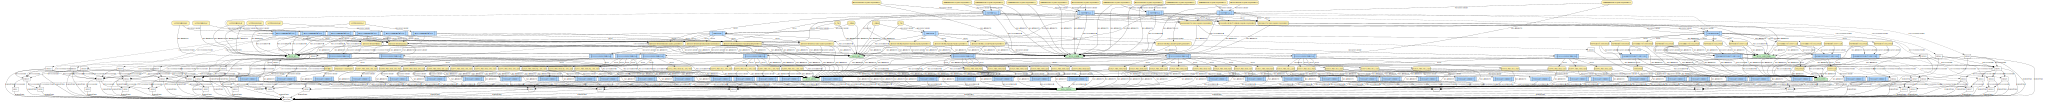

In [4]:
from rdflib import Graph, Namespace, RDF
from graphviz import Digraph
from IPython.display import display

import os

# this path is needed for grapviz to work on win
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin/'

def draw_pplan_only(a_graph):
    dot = Digraph("prov")
    for s, p, o in a_graph:
        node_str = get_a_label(a_graph, s)
        if (s, RDF.type, PPLAN.Step) in a_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label=node_str, shape="box")
        elif (s, RDF.type, PROV.Activity) in a_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label = f"<f0>|<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        if p.startswith(PPLAN):
            if "correspondsTo" in str(p):
                dot.edge(str(s), str(o), label=p.split("#")[-1], style="dashed")
            else:
                dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

def draw_prov_only(a_graph):
    dot = Digraph("prov")

    for s, p, o in a_graph:
        # classify nodes
        node_str = get_a_label(a_graph, s)
        if node_str == "":
            node_str = str(s) 
        if (s, RDF.type, PROV.Entity) in a_graph:
            dot.node(s, label=node_str, shape="box", style="rounded, filled", fillcolor="#fff2b2")
        elif (s, RDF.type, PROV.Activity) in a_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label = f"<f0> |<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        elif (s, RDF.type, PROV.SoftwareAgent) in a_graph:
            dot.node(s, label=node_str, shape="house", style="filled", fillcolor="#c2f0c2")            
    
        # add edges with labels
        if p.startswith(PROV):
            dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

def draw_prov_full(a_graph):
    dot = Digraph("prov")

    for s, p, o in a_graph:
         # classify nodes
        node_str = get_a_label(a_graph, s)
        if node_str == "":
            node_str = str(s) 
        if (s, RDF.type, PROV.Entity) in a_graph:
            dot.node(s, label=node_str, shape="box", style="rounded, filled", fillcolor="#fff2b2")
        elif (s, RDF.type, PROV.Activity) in a_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label = f"<f0>|<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        elif (s, RDF.type, PROV.SoftwareAgent) in a_graph:
            dot.node(s, label=node_str, shape="house", style="filled", fillcolor="#c2f0c2")
        elif (s, RDF.type, PPLAN.Step) in a_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label=node_str, shape="box")
            
    
        # add edges with labels
        if p.startswith(PROV):
            dot.edge(str(s), str(o), label=p.split("#")[-1])
        elif p.startswith(PPLAN):
            if "correspondsTo" in str(p):
                dot.edge(str(s), str(o), label=p.split("#")[-1], style="dashed")
            else:
                dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

graph_file = Path(output_path, "prov_full") 
dot_prov_full = draw_prov_full(roc_graph)
dot_prov_full.render(graph_file, format="png")
display(dot_prov_full)

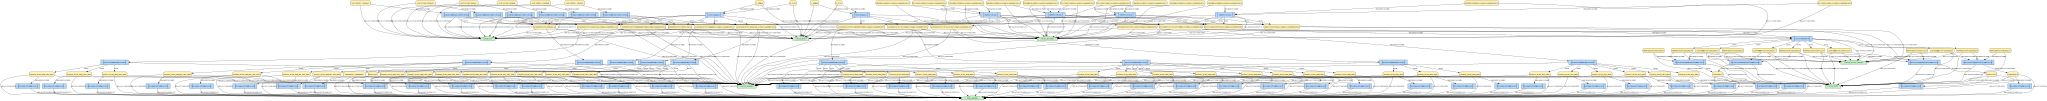

In [5]:
graph_file = Path(output_path, "prov_only") 
prov_dot = draw_prov_only(roc_graph)
prov_dot.render(graph_file, format="png")
display(prov_dot)

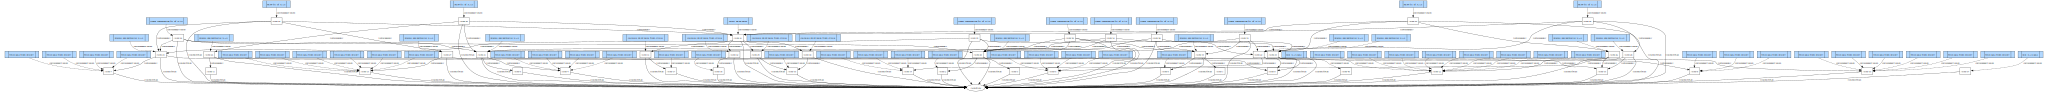

In [6]:
graph_file = Path(output_path, "pplan_only") 

plan_dot = draw_pplan_only(roc_graph)
plan_dot.render(graph_file, format="png")
display(plan_dot)

# Present provenance in table
We need to build a table from the RDF graph. The table shows the activity, the agent, the resulting dataset and the inputs that helped creating it.

activity -> agent/tool -> Entity (dataset) -> inputs 


In [7]:
# put provenance in a table structure
import pandas as pd
# present data as html table
from IPython.display import display, HTML

qres = roc_graph.query("""
PREFIX prov:   <http://www.w3.org/ns/prov#>
PREFIX skos:   <http://www.w3.org/2004/02/skos/core#>
PREFIX rdfs:  <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema:<https://schema.org/>
PREFIX pplan: <https://vocab.linkeddata.es/p-plan#>

SELECT
  ?step
  ?dataset
  ?activityLabel
  ?tools
  ?inputs
WHERE {
  # --------------------------------------------------
  # core relation
  # --------------------------------------------------
  ?output prov:wasGeneratedBy ?activity .

  # --------------------------------------------------
  # output (dataset) label — ONE label per output
  # --------------------------------------------------
  OPTIONAL {
    SELECT ?output
           (COALESCE(MAX(?pref), MAX(?name), MAX(?label), STR(?output)) AS ?dataset)
    WHERE {
      OPTIONAL { ?output skos:prefLabel ?pref }
      OPTIONAL { ?output schema:name    ?name }
      OPTIONAL { ?output rdfs:label     ?label }
    }
    GROUP BY ?output
  } 

  # --------------------------------------------------
  # wf step — related to activity
  # --------------------------------------------------
  OPTIONAL {
    SELECT ?activity
           ?step
    WHERE {
      ?activity pplan:correspondsToStep ?step .
    }
  }

  # --------------------------------------------------
  # activity label — ONE label per activity
  # --------------------------------------------------
  OPTIONAL {
    SELECT ?activity
           (COALESCE(MAX(?pref), MAX(?name), MAX(?label), STR(?activity)) AS ?activityLabel)
    WHERE {
      OPTIONAL { ?activity skos:prefLabel ?pref }
      OPTIONAL { ?activity schema:name    ?name }
      OPTIONAL { ?activity rdfs:label     ?label }
    }
    GROUP BY ?activity
  }

  # --------------------------------------------------
  # tools / agents — MANY tools aggregated per activity
  # --------------------------------------------------
  OPTIONAL {
    SELECT ?activity
           (GROUP_CONCAT(DISTINCT COALESCE(?pref, ?name, ?label, STR(?tool)); separator=", ") AS ?tools)
    WHERE {
      ?activity prov:wasAssociatedWith ?tool .
      OPTIONAL { ?tool skos:prefLabel ?pref }
      OPTIONAL { ?tool schema:name    ?name }
      OPTIONAL { ?tool rdfs:label     ?label }
    }
    GROUP BY ?activity
  }

  # --------------------------------------------------
  # inputs — MANY inputs aggregated per activity
  # --------------------------------------------------
  OPTIONAL {
    SELECT ?activity
           (GROUP_CONCAT(DISTINCT COALESCE(?pref, ?name, ?label, STR(?input)); separator=", ") AS ?inputs)
    WHERE {
      ?activity prov:used ?input .
      OPTIONAL { ?input skos:prefLabel ?pref }
      OPTIONAL { ?input schema:name    ?name }
      OPTIONAL { ?input rdfs:label     ?label }
    }
    GROUP BY ?activity
  }
}
ORDER BY ?step
""")

df = pd.DataFrame(
    [(str(s), str(a), str(t), str(o), str(i)) for s, o, a, t, i in qres],
    columns=["Step", "Activity", "Tool", "Dataset", "Inputs"]
)

In [8]:
display(HTML(df.to_html().replace("\\n","<br>")))

,Step,Activity,Tool,Dataset,Inputs
0,/step/0,fetch data from history,DATA_FETCH,Sn foil.prj,None
1,/step/10,fetch data from history,DATA_FETCH,263929_PtSn_OCH_1.dat,None
2,/step/10,fetch data from history,DATA_FETCH,263930_PtSn_OCH_2.dat,None
3,/step/10,fetch data from history,DATA_FETCH,263931_PtSn_OCH_3.dat,None
4,/step/10,fetch data from history,DATA_FETCH,263932_PtSn_OCH_4.dat,None
5,/step/10,fetch data from history,DATA_FETCH,263933_PtSn_OCH_5.dat,None
6,/step/10,fetch data from history,DATA_FETCH,263934_PtSn_OCH_6.dat,None
7,/step/12,fetch data from history,DATA_FETCH,263824_PtSn_OCH_1.dat,None
8,/step/12,fetch data from history,DATA_FETCH,263825_PtSn_OCH_2.dat,None
9,/step/12,fetch data from history,DATA_FETCH,263826_PtSn_OCH_3.dat,None


# Datasets in Detail
Using the PROV-O file, we can get the details of each dataset and display them in a user friendly way


In [9]:
# get a dict of dataset details
def get_dataset_properties(a_dataset, a_graph):
    ds_data = []
    relations = list(a_graph.predicate_objects(a_dataset))
    ds_data = [[p, o] for p, o in relations]
    return ds_data

def get_ds_dataframe(ds_details, a_graph):
    processed_properties = []
    for p, o in ds_details:
        short_p = a_graph.namespace_manager.normalizeUri(p)
        short_o = a_graph.namespace_manager.normalizeUri(o) if isinstance(o, URIRef) else o
        if "prov:wasAttributedTo" == str(short_p) or \
           "prov:wasGeneratedBy" == str(short_p):
            short_o = get_a_label(a_graph, o)
        processed_properties.append([short_p, short_o])
    ds_df = pd.DataFrame(
        [(p,o) for p, o in processed_properties],
        columns=["Property", "Value"]
    )
    return ds_df

step_datasets_qry = """
PREFIX prov:   <http://www.w3.org/ns/prov#>
PREFIX pplan: <https://vocab.linkeddata.es/p-plan#>

SELECT
  ?step
  ?dataset
  ?activity
WHERE {
  ?dataset prov:wasGeneratedBy ?activity .
  OPTIONAL {
    ?activity pplan:correspondsToStep ?step .
  }
}
ORDER BY ?step
"""
qres = roc_graph.query(step_datasets_qry)

for step, a_ds, activity,  in qres:
    #print(str(step), str(dataset), str(activity))
    ds_properties = get_dataset_properties(a_ds,roc_graph)
    ds_label = get_a_label(roc_graph, a_ds)
    props_df = get_ds_dataframe(ds_properties, roc_graph)
    display(HTML(f"<h3>{ds_label} Properties</h3>") )
    display(HTML(props_df.to_html().replace("\\n","<br>")))


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,application/vnd.demeter.athena
2,dcterms:description,atsym: Nonebkg_e0: 29200edge: Nonenpts: 2094xmax: 30049.25xmin: 29000.24
3,schema1:name,datasets/Sn_foil.prj_b9b199e627b0df6d.prj
4,skos:prefLabel,Sn foil.prj
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/plain
2,dcterms:description,uploaded tabular file
3,schema1:name,datasets/263929_PtSn_OCH_1.dat_c1b1e33af4bbfb98.tabular
4,skos:prefLabel,263929_PtSn_OCH_1.dat
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/plain
2,dcterms:description,uploaded tabular file
3,schema1:name,datasets/263930_PtSn_OCH_2.dat_2dce3cba98f791fe.tabular
4,skos:prefLabel,263930_PtSn_OCH_2.dat
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/plain
2,dcterms:description,uploaded tabular file
3,schema1:name,datasets/263931_PtSn_OCH_3.dat_c289466c92d2c272.tabular
4,skos:prefLabel,263931_PtSn_OCH_3.dat
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/plain
2,dcterms:description,uploaded tabular file
3,schema1:name,datasets/263932_PtSn_OCH_4.dat_8392e1ce86b3f444.tabular
4,skos:prefLabel,263932_PtSn_OCH_4.dat
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_athena


...

,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/plain
2,dcterms:description,uploaded tabular file
3,schema1:name,datasets/262880_PtSn_OCA_Abu_3.dat_c2de473dd283bcf1.tabular
4,skos:prefLabel,262880_PtSn_OCA_Abu_3.dat
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/plain
2,dcterms:description,uploaded tabular file
3,schema1:name,datasets/262881_PtSn_OCA_Abu_4.dat_db463272d57e0530.tabular
4,skos:prefLabel,262881_PtSn_OCA_Abu_4.dat
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/plain
2,dcterms:description,uploaded tabular file
3,schema1:name,datasets/262875_PtSn_OCO_Abu_1.dat_a2ddc3fedfe1b725.tabular
4,skos:prefLabel,262875_PtSn_OCO_Abu_1.dat
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/plain
2,dcterms:description,uploaded tabular file
3,schema1:name,datasets/262876_PtSn_OCO_Abu_2.dat_4788d985a9c586e4.tabular
4,skos:prefLabel,262876_PtSn_OCO_Abu_2.dat
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/plain
2,dcterms:description,uploaded tabular file
3,schema1:name,datasets/262877_PtSn_OCO_Abu_3.dat_0130dc9d5e228c18.tabular
4,skos:prefLabel,262877_PtSn_OCO_Abu_3.dat
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_athena


# Ready to publish RO-Crate

At this stage we can publish the RO-Crate and the discovery metadata we have. This includes
 - provenance of each dataset consumed or generated
 - metadata about each dataset
 - Identify XAS datasets (fes2_rt01_mar02.xmu, FeS2_athena, fit_report_FeS2). 

More advanced processing would entail also looking at tool parameters, so there is better understanding of the details of the provenance chain, if needed.